# Notebook 17 — Perceptrón multicapa con TensorFlow/Keras

En este notebook estudiaremos cómo construir una red neuronal densa para un problema de clasificación binaria.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la estructura de un perceptrón multicapa;
- preparar datos para una red neuronal;
- construir un modelo con `TensorFlow/Keras`;
- interpretar capas, neuronas y funciones de activación;
- compilar una red con pérdida, optimizador y métricas;
- entrenar el modelo;
- analizar curvas de pérdida y accuracy;
- utilizar un conjunto de validación;
- aplicar `EarlyStopping`;
- generar probabilidades y clases;
- visualizar la frontera de decisión;
- reconocer señales de overfitting;
- comparar distintas arquitecturas.

Usaremos el dataset sintético `make_moons` de `scikit-learn`.

## 1. Instalación

Si TensorFlow no está instalado en tu entorno, ejecuta:

```python
%pip install tensorflow
```

Después reinicia el kernel.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format

print("Versión de TensorFlow:", tf.__version__)


/Users/brauliopinaamaros/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Versión de TensorFlow: 2.20.0


## 2. Generación de datos sintéticos

`make_moons` produce dos clases con una frontera no lineal.

Este tipo de patrón permite mostrar por qué una red neuronal con capas ocultas puede superar a un clasificador lineal.

In [2]:
X, y = make_moons(
    n_samples=1_500,
    noise=0.24,
    random_state=RANDOM_STATE,
)

print(X.shape)
print(np.bincount(y))


(1500, 2)
[750 750]


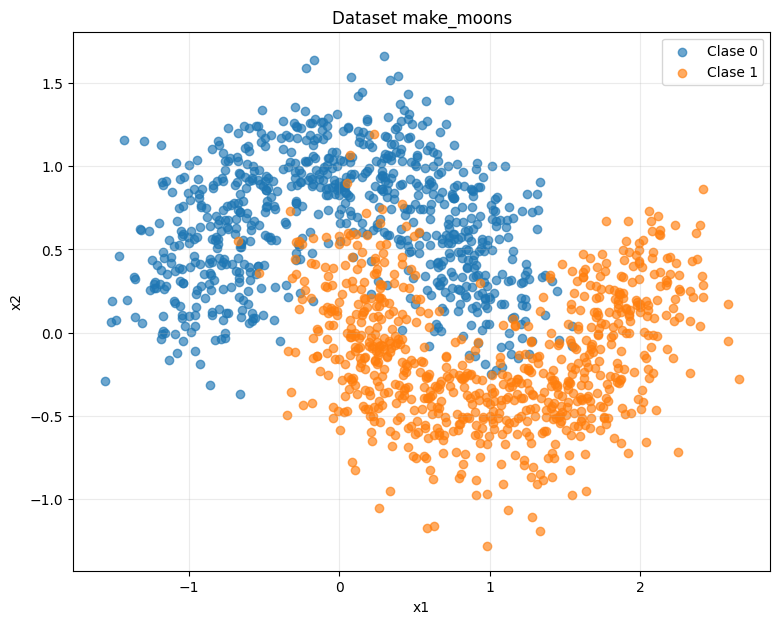

In [3]:
plt.figure(figsize=(9, 7))

for class_value in np.unique(y):
    mask = y == class_value

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        alpha=0.65,
        label=f"Clase {class_value}",
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset make_moons")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 3. Split de entrenamiento, validación y prueba

Separaremos:

- 60% para entrenamiento;
- 20% para validación;
- 20% para prueba.

La validación se utilizará para monitorear el entrenamiento.  
El test se reservará para la evaluación final.

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)


Train: (900, 2)
Validation: (300, 2)
Test: (300, 2)


## 4. Escalamiento

Las redes neuronales suelen entrenar mejor cuando las variables tienen escalas comparables.

El escalador se ajusta únicamente con entrenamiento.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)


## 5. ¿Qué es un perceptrón multicapa?

Una neurona artificial calcula:

\[
z = w^\top x + b
\]

y después aplica una función de activación:

\[
a = \phi(z).
\]

Un MLP combina varias capas:

\[
x
\rightarrow
\text{capa oculta}
\rightarrow
\text{capa oculta}
\rightarrow
\widehat{y}.
\]

Las capas ocultas permiten aprender relaciones no lineales.

## 6. Construcción del modelo

Usaremos:

- dos variables de entrada;
- dos capas ocultas;
- activación ReLU;
- una salida sigmoide para clasificación binaria.

In [6]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(
        units=16,
        activation="relu",
        name="hidden_1",
    ),
    layers.Dense(
        units=8,
        activation="relu",
        name="hidden_2",
    ),
    layers.Dense(
        units=1,
        activation="sigmoid",
        name="output",
    ),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Interpretación

- `Dense(16)`: capa con 16 neuronas.
- `relu`: activación no lineal.
- `Dense(1, sigmoid)`: produce una probabilidad entre 0 y 1.

El número de parámetros depende del número de entradas, neuronas y sesgos.

## 7. Compilación

Debemos especificar:

- función de pérdida;
- optimizador;
- métricas.

Para clasificación binaria utilizaremos entropía cruzada binaria:

\[
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\widehat{p}_i)
+
(1-y_i)\log(1-\widehat{p}_i)
\right].
\]

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
    ],
)


## 8. Entrenamiento inicial

Una época corresponde a un recorrido completo por los datos de entrenamiento.

`batch_size` indica cuántas observaciones se utilizan antes de actualizar los pesos.

In [8]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_validation_scaled,
        y_validation,
    ),
    epochs=120,
    batch_size=32,
    verbose=0,
)

history.history.keys()


dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss'])

## 9. Curvas de aprendizaje

Las curvas de entrenamiento y validación ayudan a detectar overfitting.

In [9]:
history_df = pd.DataFrame(
    history.history
)

history_df.head()


,accuracy,auc,loss,val_accuracy,val_auc,val_loss
0,0.4867,0.2433,0.7611,0.4600,0.3980,0.7276
1,0.5144,0.5817,0.6948,0.5800,0.7084,0.6739
2,0.6733,0.8176,0.6499,0.7467,0.8801,0.6292
3,0.8089,0.9033,0.6071,0.8633,0.9286,0.5760
4,0.8500,0.9257,0.5470,0.8800,0.9471,0.4967


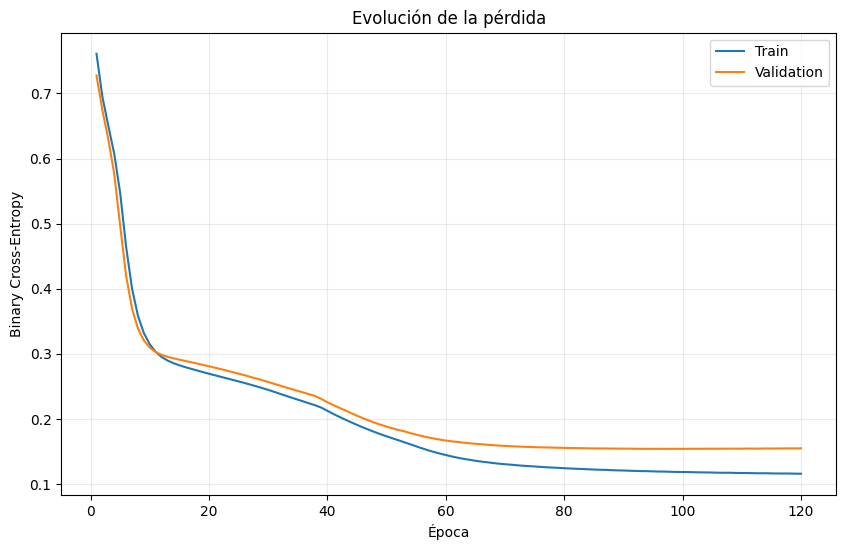

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    label="Train",
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    label="Validation",
)

plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy")
plt.title("Evolución de la pérdida")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


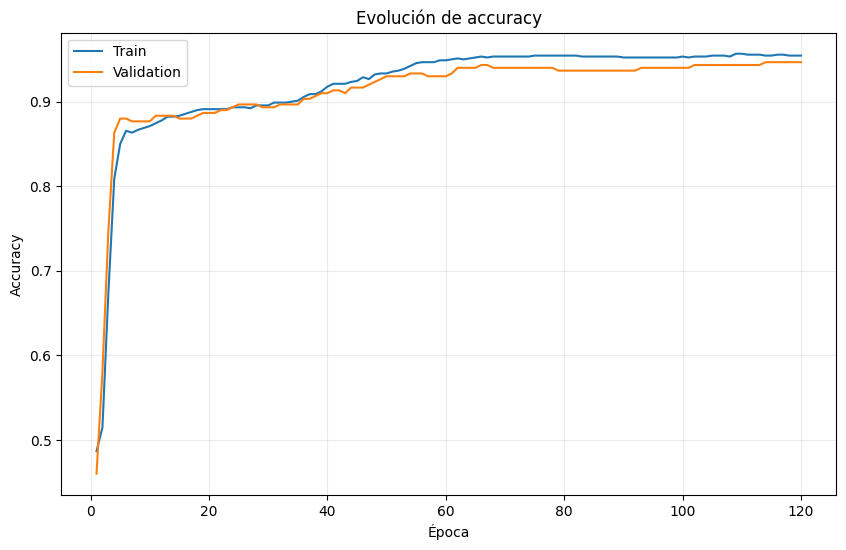

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    label="Train",
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    label="Validation",
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución de accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Una pérdida de entrenamiento decreciente acompañada por una pérdida de validación creciente es una señal típica de overfitting.

## 10. Early Stopping

`EarlyStopping` detiene el entrenamiento cuando la métrica de validación deja de mejorar.

Con `restore_best_weights=True`, el modelo recupera los pesos de la mejor época.

In [12]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
)

model_early_stopping = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_early_stopping.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
    ],
)

history_early = model_early_stopping.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_validation_scaled,
        y_validation,
    ),
    epochs=400,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

print(
    "Épocas ejecutadas:",
    len(history_early.history["loss"]),
)


Épocas ejecutadas: 67


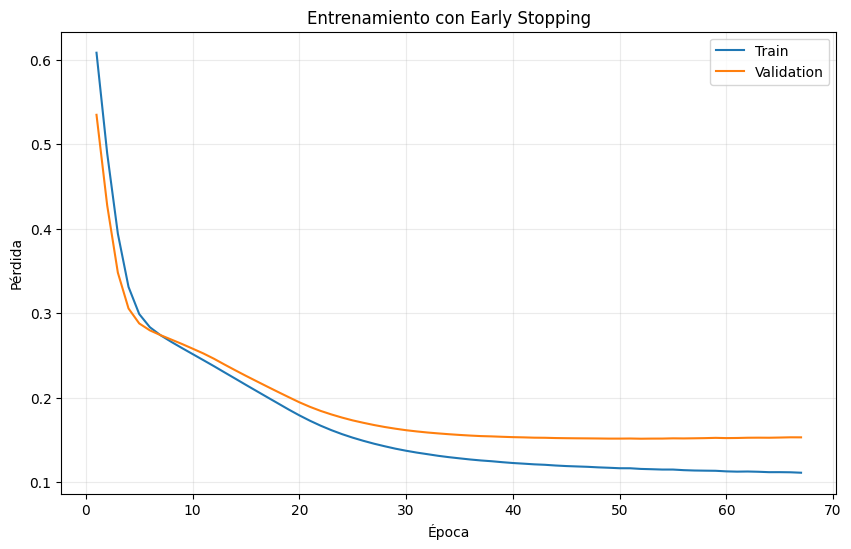

In [13]:
history_early_df = pd.DataFrame(
    history_early.history
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_early_df.index + 1,
    history_early_df["loss"],
    label="Train",
)

plt.plot(
    history_early_df.index + 1,
    history_early_df["val_loss"],
    label="Validation",
)

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Entrenamiento con Early Stopping")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 11. Evaluación final

Primero obtendremos probabilidades.  
Después aplicaremos un umbral de 0.5 para obtener clases.

In [14]:
test_probabilities = (
    model_early_stopping
    .predict(
        X_test_scaled,
        verbose=0,
    )
    .ravel()
)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

test_metrics = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "F1",
        "ROC-AUC",
    ],
    "Valor": [
        accuracy_score(
            y_test,
            test_predictions,
        ),
        f1_score(
            y_test,
            test_predictions,
        ),
        roc_auc_score(
            y_test,
            test_probabilities,
        ),
    ],
})

test_metrics


,Métrica,Valor
0,Accuracy,0.9300
1,F1,0.9298
2,ROC-AUC,0.9858


In [15]:
print(
    classification_report(
        y_test,
        test_predictions,
        digits=4,
    )
)


              precision    recall  f1-score   support

           0     0.9272    0.9333    0.9302       150
           1     0.9329    0.9267    0.9298       150

    accuracy                         0.9300       300
   macro avg     0.9300    0.9300    0.9300       300
weighted avg     0.9300    0.9300    0.9300       300



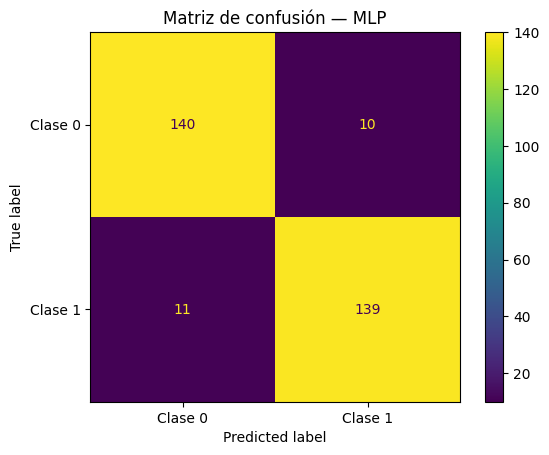

In [16]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test,
        test_predictions,
    ),
    display_labels=["Clase 0", "Clase 1"],
).plot()

plt.title("Matriz de confusión — MLP")
plt.show()


## 12. Frontera de decisión

Visualizaremos la clase predicha sobre una malla de puntos.

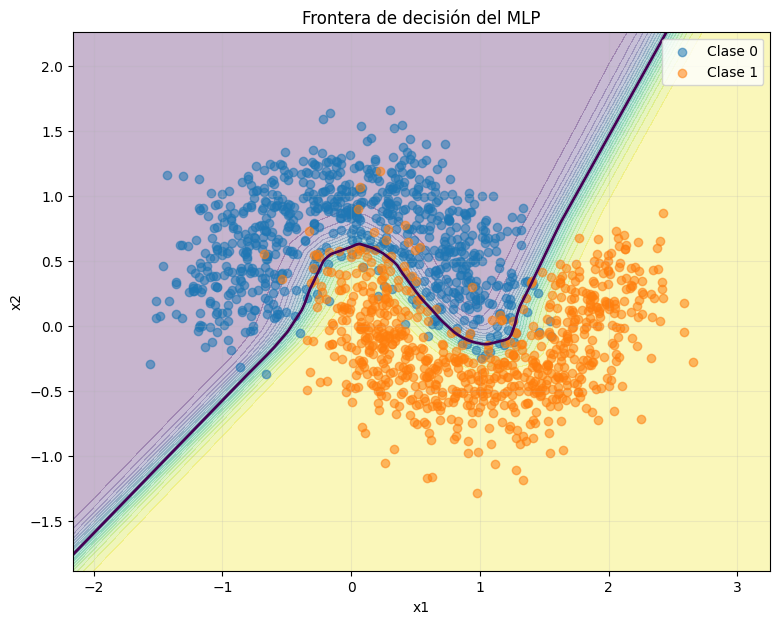

In [17]:
x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500),
)

grid = np.c_[
    xx.ravel(),
    yy.ravel(),
]

grid_scaled = scaler.transform(grid)

grid_probabilities = (
    model_early_stopping
    .predict(
        grid_scaled,
        verbose=0,
    )
    .reshape(xx.shape)
)

plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    grid_probabilities,
    levels=np.linspace(0, 1, 21),
    alpha=0.30,
)

plt.contour(
    xx,
    yy,
    grid_probabilities,
    levels=[0.5],
    linewidths=2,
)

for class_value in np.unique(y):
    mask = y == class_value

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        alpha=0.55,
        label=f"Clase {class_value}",
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Frontera de decisión del MLP")
plt.legend()
plt.grid(alpha=0.20)
plt.show()


## 13. Efecto del umbral

La red produce probabilidades. La clase final depende del umbral.

In [18]:
threshold_rows = []

for threshold in [
    0.20,
    0.35,
    0.50,
    0.65,
    0.80,
]:
    predictions_threshold = (
        test_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "Umbral": threshold,
        "Accuracy": accuracy_score(
            y_test,
            predictions_threshold,
        ),
        "F1": f1_score(
            y_test,
            predictions_threshold,
        ),
        "Positivos predichos": (
            predictions_threshold.sum()
        ),
    })

pd.DataFrame(threshold_rows)


,Umbral,Accuracy,F1,Positivos predichos
0,0.2000,0.9233,0.9279,169
1,0.3500,0.9333,0.9359,162
2,0.5000,0.9300,0.9298,149
3,0.6500,0.9333,0.9315,142
4,0.8000,0.9267,0.9236,138


## 14. Comparación de arquitecturas

Compararemos redes con diferente capacidad.

Para mantener el ejemplo sencillo, todas usarán Early Stopping.

In [19]:
architectures = {
    "Sin capa oculta": [],
    "Pequeña": [8],
    "Media": [16, 8],
    "Grande": [64, 32, 16],
}

architecture_rows = []

for architecture_name, hidden_units in architectures.items():

    network = keras.Sequential()
    network.add(
        layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    )

    for units in hidden_units:
        network.add(
            layers.Dense(
                units,
                activation="relu",
            )
        )

    network.add(
        layers.Dense(
            1,
            activation="sigmoid",
        )
    )

    network.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001,
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
    )

    architecture_history = network.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_validation_scaled,
            y_validation,
        ),
        epochs=250,
        batch_size=32,
        callbacks=[callback],
        verbose=0,
    )

    probabilities = (
        network
        .predict(
            X_test_scaled,
            verbose=0,
        )
        .ravel()
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    architecture_rows.append({
        "Arquitectura": architecture_name,
        "Capas ocultas": str(hidden_units),
        "Parámetros": network.count_params(),
        "Épocas": len(
            architecture_history.history["loss"]
        ),
        "Accuracy test": accuracy_score(
            y_test,
            predictions,
        ),
        "F1 test": f1_score(
            y_test,
            predictions,
        ),
        "ROC-AUC test": roc_auc_score(
            y_test,
            probabilities,
        ),
    })

architecture_table = pd.DataFrame(
    architecture_rows
)

architecture_table


,Arquitectura,Capas ocultas,Parámetros,Épocas,Accuracy test,F1 test,ROC-AUC test
0,Sin capa oculta,[],3,237,0.8700,0.8687,0.9461
1,Pequeña,[8],33,250,0.9267,0.9262,0.9838
2,Media,"[16, 8]",193,92,0.9433,0.9435,0.9864
3,Grande,"[64, 32, 16]",2817,29,0.9433,0.9435,0.9852


Una red más grande no garantiza mejor generalización. La arquitectura debe seleccionarse mediante validación.

## 15. Regularización con Dropout

Dropout desactiva aleatoriamente una proporción de activaciones durante el entrenamiento.

Esto puede reducir dependencia excesiva entre neuronas y ayudar a controlar overfitting.

In [20]:
dropout_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid"),
])

dropout_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

dropout_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

dropout_history = dropout_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_validation_scaled,
        y_validation,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[dropout_callback],
    verbose=0,
)

dropout_probabilities = (
    dropout_model
    .predict(
        X_test_scaled,
        verbose=0,
    )
    .ravel()
)

dropout_predictions = (
    dropout_probabilities >= 0.5
).astype(int)

pd.DataFrame({
    "Métrica": ["Accuracy", "F1", "ROC-AUC"],
    "Valor": [
        accuracy_score(
            y_test,
            dropout_predictions,
        ),
        f1_score(
            y_test,
            dropout_predictions,
        ),
        roc_auc_score(
            y_test,
            dropout_probabilities,
        ),
    ],
})


,Métrica,Valor
0,Accuracy,0.9467
1,F1,0.9467
2,ROC-AUC,0.9859


## 16. Errores frecuentes

1. No escalar las variables.
2. Utilizar test como conjunto de validación.
3. Entrenar demasiadas épocas sin monitorear validación.
4. Suponer que una red más profunda siempre es mejor.
5. Confundir accuracy con función de pérdida.
6. Usar una salida incorrecta para el tipo de problema.
7. Usar `softmax` con una sola neurona en clasificación binaria.
8. Ignorar el efecto del `learning_rate`.
9. No fijar semillas cuando se necesita reproducibilidad.
10. Interpretar probabilidades como perfectamente calibradas.
11. Comparar arquitecturas con diferentes splits.
12. No conservar el mejor modelo.

## 17. Experimentos sugeridos

1. Cambia el número de neuronas.
2. Agrega o elimina capas ocultas.
3. Compara ReLU con `tanh`.
4. Cambia el `learning_rate`.
5. Modifica el `batch_size`.
6. Aumenta el ruido de `make_moons`.
7. Compara entrenamiento con y sin Early Stopping.
8. Compara con y sin Dropout.
9. Cambia el umbral de clasificación.
10. Compara el MLP contra regresión logística, KNN y SVM.

## 18. Resumen

En este notebook:

- preparamos datos para una red neuronal;
- construimos un MLP con Keras;
- utilizamos capas densas, ReLU y sigmoide;
- compilamos con Adam y entropía cruzada;
- analizamos curvas de aprendizaje;
- aplicamos Early Stopping;
- evaluamos probabilidades y clases;
- visualizamos la frontera de decisión;
- comparamos arquitecturas;
- introdujimos Dropout.

Un MLP puede aprender fronteras no lineales muy flexibles, pero requiere decisiones cuidadosas sobre arquitectura, optimización, regularización y validación.